In [1]:
# This notebook is proposed to spot anxiety data and non-anxiety data
# by validating optical flow computation using OpenCV with CUDA support.

#!/usr/bin/env python3

# Adjust the system path to include the parent directory
import sys
sys.path.append('..')

# Syncing the source module with current notebook environment
# This module will automatically running the module syncronization script
import module

print("Anxiety data validation notebook")

Anxiety data validation notebook


In [2]:
# Define video file paths
ANXIETY_DATA_PATH       = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520125029.avi'
NON_ANXIETY_DATA_PATH   = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520132508.avi'

In [4]:
import cv2
import numpy as np
from src.features.apex import TVL1
from typing import List


tvl1 = TVL1()


def process_video_optical_flow(video_path: str) -> List[float]:
    """
    Process a video file to compute mean optical flow magnitude between consecutive frames.

    Args:
        video_path (str): Path to the video file.

    Returns:
        List[float]: A list of mean optical flow magnitudes for each frame pair.

    Raises:
        RuntimeError: If the video file cannot be opened or frames cannot be read.
    """
    
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    magnitude_stats = []

    ret, prev_frame = cap.read()

    if not ret:
        raise RuntimeError("Failed to read first frame.")

    for frame_idx in range(1, total_frames):
        ret, current_frame = cap.read()

        if not ret:
            raise RuntimeError(f"Failed to read frame at index {frame_idx}.")

        mag = tvl1.compute(prev_frame, current_frame).magnitude()
        mean_val = np.mean(mag)

        magnitude_stats.append(mean_val)
        prev_frame = current_frame


    cap.release()

    return magnitude_stats

Total frames in video: 2689


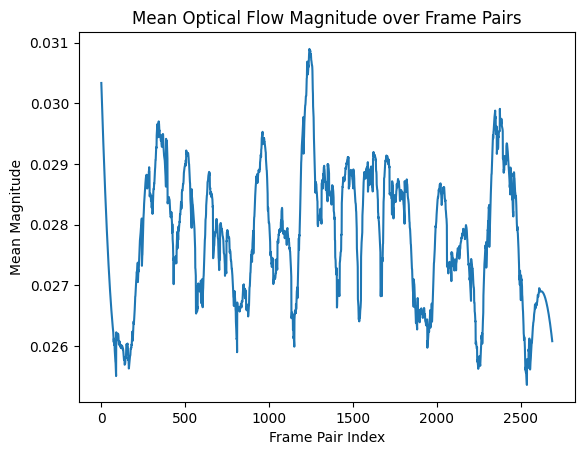

In [5]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt


VIDEO_PATH = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520125029.avi'

magnitude_stats = process_video_optical_flow(VIDEO_PATH) 
smooted_stats   = savgol_filter(magnitude_stats, window_length=144, polyorder=2)

plt.plot(smooted_stats)
plt.title('Mean Optical Flow Magnitude over Frame Pairs')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

Total frames in video: 2697


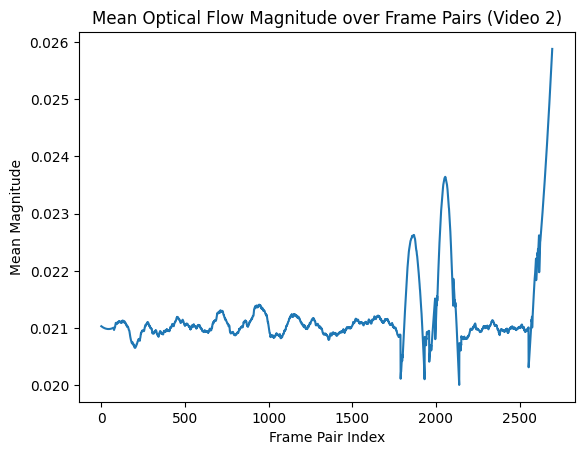

In [6]:
from scipy.signal import savgol_filter


VIDEO_PATH2 = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520132508.avi'

magnitude_stats2 = process_video_optical_flow(VIDEO_PATH2)
smooted_stats2   = savgol_filter(magnitude_stats2, window_length=144, polyorder=2)

plt.plot(smooted_stats2)
plt.title('Mean Optical Flow Magnitude over Frame Pairs (Video 2)')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

In [7]:
import numpy as np


def extract_stats(mag):
    arr = np.array(mag)
    
    return {
        'std': np.std(arr),
        'variance': np.var(arr),
        'coef_variation': np.std(arr) / np.mean(arr) if np.mean(arr) != 0 else 0,
        'range': np.max(arr) - np.min(arr),
        'iqr': np.percentile(arr, 75) - np.percentile(arr, 25),
        'zero_crossings': np.sum(np.diff(np.sign(arr)) != 0),
        'mean_abs_diff': np.mean(np.abs(np.diff(arr))),
        'num_peaks': len(np.where(np.diff(np.sign(np.diff(arr))) < 0)[0]),
        'high_freq_energy': np.sum(np.fft.fft(arr)**2) / len(arr),
    }


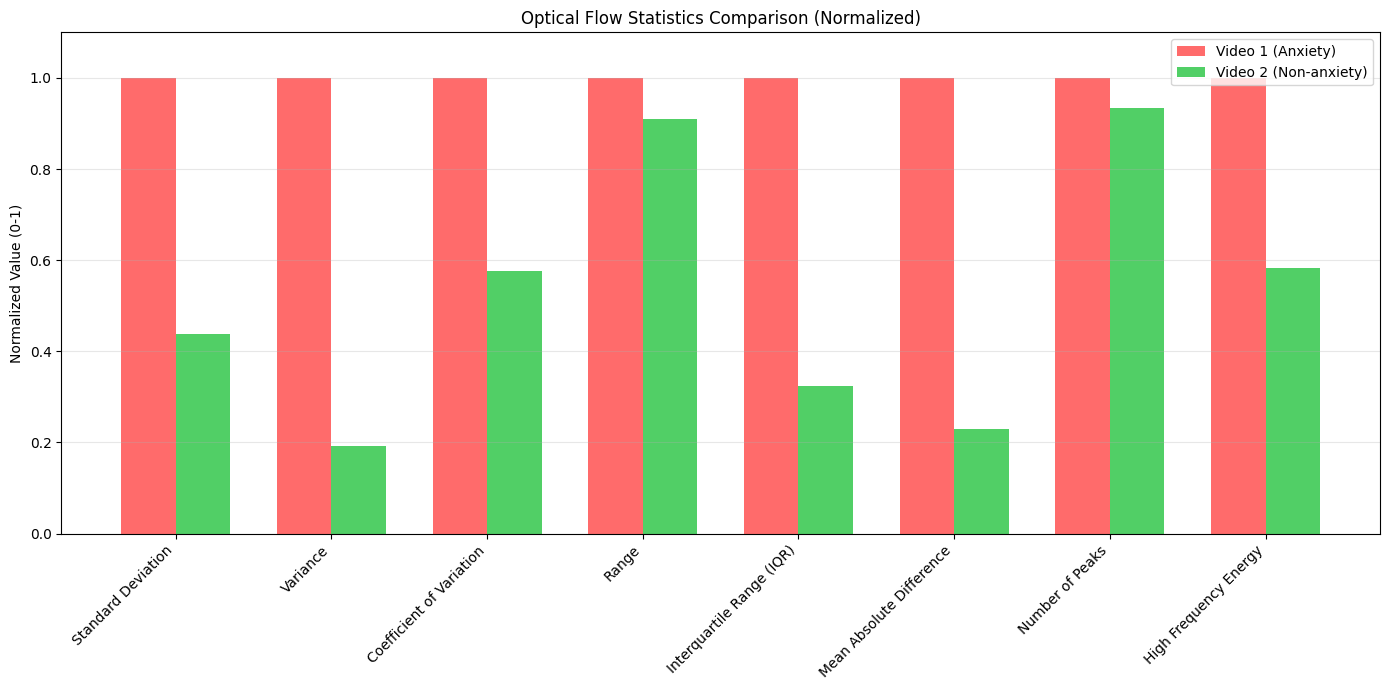

Standard Deviation: Video 1 = 0.007381838746368885, Video 2 = 0.0032384374644607306
Variance: Video 1 = 5.449154559755698e-05, Video 2 = 1.0487477084097918e-05
Coefficient of Variation: Video 1 = 0.2653021812438965, Video 2 = 0.15263350307941437
Range: Video 1 = 0.08535733073949814, Video 2 = 0.07766735553741455
Interquartile Range (IQR): Video 1 = 0.0026894542388617992, Video 2 = 0.0008700089529156685
Mean Absolute Difference: Video 1 = 0.004489656072109938, Video 2 = 0.0010304002789780498
Number of Peaks: Video 1 = 881, Video 2 = 822
High Frequency Energy: Video 1 = 2.079157152902299, Video 2 = 1.213249380432162


In [8]:
import matplotlib.pyplot as plt
import numpy as np


stats1 = extract_stats(magnitude_stats)
stats2 = extract_stats(magnitude_stats2)

metrics = {
    'Standard Deviation': (stats1['std'], stats2['std']),
    'Variance': (stats1['variance'], stats2['variance']),
    'Coefficient of Variation': (stats1['coef_variation'], stats2['coef_variation']),
    'Range': (stats1['range'], stats2['range']),
    'Interquartile Range (IQR)': (stats1['iqr'], stats2['iqr']),
    'Mean Absolute Difference': (stats1['mean_abs_diff'], stats2['mean_abs_diff']),
    'Number of Peaks': (stats1['num_peaks'], stats2['num_peaks']),
    'High Frequency Energy': (abs(stats1['high_freq_energy']), abs(stats2['high_freq_energy'])),
}

normalized_metrics = {}
for name, (v1, v2) in metrics.items():
    max_val = max(v1, v2)
    if max_val > 0:
        normalized_metrics[name] = (v1/max_val, v2/max_val)
    else:
        normalized_metrics[name] = (0, 0)

x = list(normalized_metrics.keys())
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(np.arange(len(x)) - width/2, [v[0] for v in normalized_metrics.values()], 
               width, label='Video 1 (Anxiety)', color='#ff6b6b')
bars2 = ax.bar(np.arange(len(x)) + width/2, [v[1] for v in normalized_metrics.values()], 
               width, label='Video 2 (Non-anxiety)', color='#51cf66')

ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x, rotation=45, ha='right')
ax.set_ylabel('Normalized Value (0-1)')
ax.set_title('Optical Flow Statistics Comparison (Normalized)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


for name, (v1, v2) in metrics.items():
    print(f"{name}: Video 1 = {v1}, Video 2 = {v2}")

In [9]:
# Compute optical flow with focus on ROI areas

import cv2
import numpy as np
import mediapipe as mp
from src.features.apex import TVL1


mp_face_mesh    = mp.solutions.face_mesh
face_mesh       = mp_face_mesh.FaceMesh(static_image_mode=False, 
                                        max_num_faces=1,
                                        refine_landmarks=True,
                                        min_detection_confidence=0.5,
                                        min_tracking_confidence=0.5)

tvl1 = TVL1()


def process_video_optical_flow_roi(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    magnitude_stats = []

    ret, prev_frame = cap.read()

    if not ret:
        raise RuntimeError("Failed to read first frame.")

    for frame_idx in range(1, total_frames):
        ret, current_frame = cap.read()

        if not ret:
            raise RuntimeError(f"Failed to read frame at index {frame_idx}.")

        rgb_prev = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2RGB)
        rgb_curr = cv2.cvtColor(current_frame, cv2.COLOR_BGR2RGB)

        results_prev = face_mesh.process(rgb_prev)
        results_curr = face_mesh.process(rgb_curr)

        if results_prev.multi_face_landmarks and results_curr.multi_face_landmarks:
            landmarks_prev = results_prev.multi_face_landmarks[0].landmark
            landmarks_curr = results_curr.multi_face_landmarks[0].landmark

            h, w, _ = prev_frame.shape
            roi_prev = np.array([(int(lm.x * w), int(lm.y * h)) for lm in landmarks_prev])
            # roi_curr = np.array([(int(lm.x * w), int(lm.y * h)) for lm in landmarks_curr])

            x, y, w_roi, h_roi = cv2.boundingRect(roi_prev)
            roi_prev_cropped = prev_frame[y:y+h_roi, x:x+w_roi]
            roi_curr_cropped = current_frame[y:y+h_roi, x:x+w_roi]

            mag = tvl1.compute(roi_prev_cropped, roi_curr_cropped).magnitude()
            mean_val = np.mean(mag)

            magnitude_stats.append(mean_val)

        prev_frame = current_frame

    cap.release()

    return magnitude_stats

I0000 00:00:1765081623.189689   13342 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1765081623.191809   13798 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.25.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1765081623.200607   13777 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765081623.213633   13792 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Total frames in video: 2689


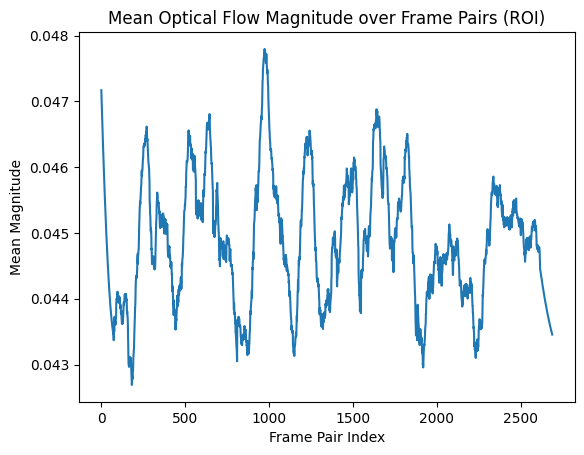

In [11]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt


VIDEO_PATH = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520125029.avi'

magnitude_stats_roi = process_video_optical_flow_roi(VIDEO_PATH)
smooted_stats_roi   = savgol_filter(magnitude_stats_roi, window_length=144, polyorder=2)

plt.plot(smooted_stats_roi)
plt.title('Mean Optical Flow Magnitude over Frame Pairs (ROI)')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

Total frames in video: 2697


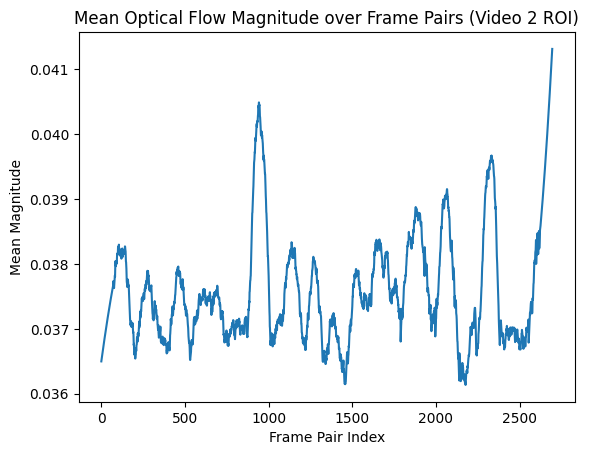

In [12]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt


VIDEO_PATH2 = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520132508.avi'

magnitude_stats2_roi = process_video_optical_flow_roi(VIDEO_PATH2)
smooted_stats2_roi   = savgol_filter(magnitude_stats2_roi, window_length=144, polyorder=2)

plt.plot(smooted_stats2_roi)
plt.title('Mean Optical Flow Magnitude over Frame Pairs (Video 2 ROI)')
plt.xlabel('Frame Pair Index')
plt.ylabel('Mean Magnitude')
plt.show()

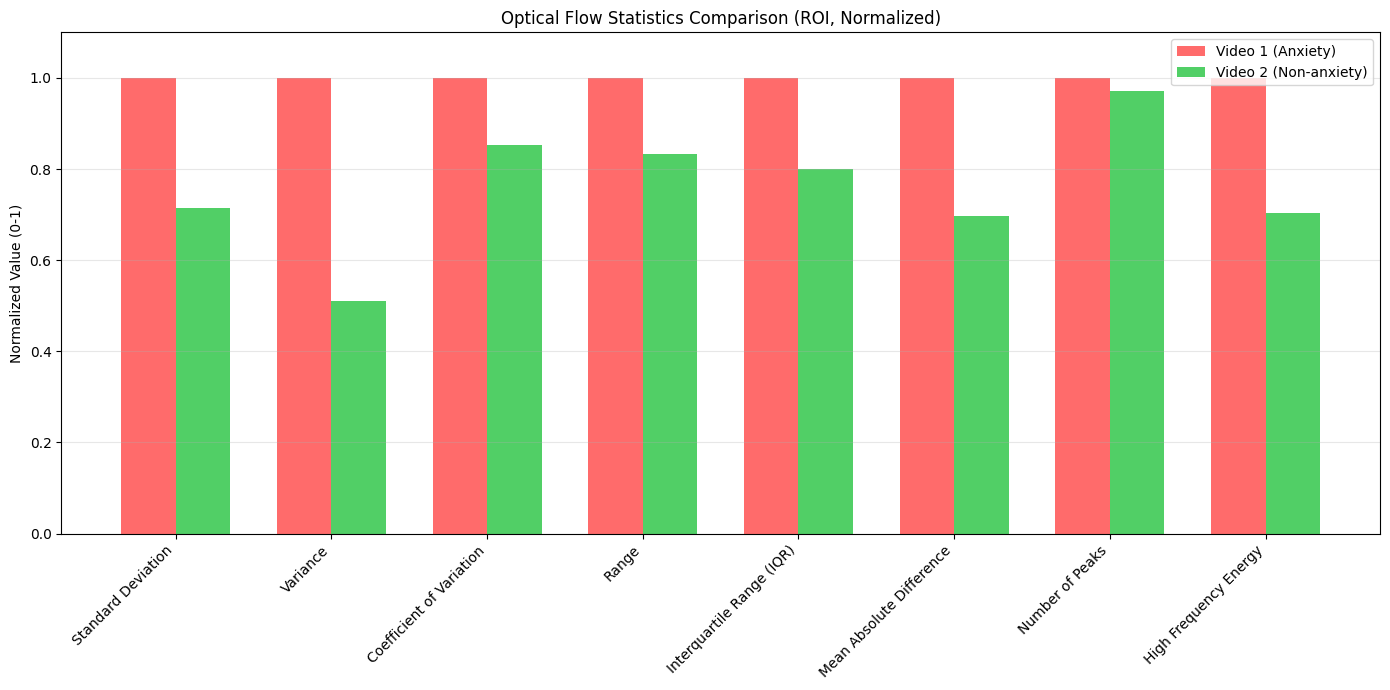

Standard Deviation: Video 1 = 0.005097266752272844, Video 2 = 0.003643408417701721
Variance: Video 1 = 2.5982126317103393e-05, Video 2 = 1.327442532783607e-05
Coefficient of Variation: Video 1 = 0.11357500404119492, Video 2 = 0.09692610055208206
Range: Video 1 = 0.06528548151254654, Video 2 = 0.054324179887771606
Interquartile Range (IQR): Video 1 = 0.004930410534143448, Video 2 = 0.003940945491194725
Mean Absolute Difference: Video 1 = 0.004575367551296949, Video 2 = 0.003193335374817252
Number of Peaks: Video 1 = 858, Video 2 = 833
High Frequency Energy: Video 1 = 5.4146354512171335, Video 2 = 3.8098519190427753


In [13]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt


stats1_roi = extract_stats(magnitude_stats_roi)
stats2_roi = extract_stats(magnitude_stats2_roi)

metrics = {
    'Standard Deviation': (stats1_roi['std'], stats2_roi['std']),
    'Variance': (stats1_roi['variance'], stats2_roi['variance']),
    'Coefficient of Variation': (stats1_roi['coef_variation'], stats2_roi['coef_variation']),
    'Range': (stats1_roi['range'], stats2_roi['range']),
    'Interquartile Range (IQR)': (stats1_roi['iqr'], stats2_roi['iqr']),
    'Mean Absolute Difference': (stats1_roi['mean_abs_diff'], stats2_roi['mean_abs_diff']),
    'Number of Peaks': (stats1_roi['num_peaks'], stats2_roi['num_peaks']),
    'High Frequency Energy': (abs(stats1_roi['high_freq_energy']), abs(stats2_roi['high_freq_energy'])),
}

normalized_metrics = {}

for name, (v1, v2) in metrics.items():
    max_val = max(v1, v2)
    if max_val > 0:
        normalized_metrics[name] = (v1/max_val, v2/max_val)
    else:
        normalized_metrics[name] = (0, 0)

x = list(normalized_metrics.keys())
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(np.arange(len(x)) - width/2, [v[0] for v in normalized_metrics.values()], 
               width, label='Video 1 (Anxiety)', color='#ff6b6b')
bars2 = ax.bar(np.arange(len(x)) + width/2, [v[1] for v in normalized_metrics.values()], 
               width, label='Video 2 (Non-anxiety)', color='#51cf66')

ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x, rotation=45, ha='right')
ax.set_ylabel('Normalized Value (0-1)')
ax.set_title('Optical Flow Statistics Comparison (ROI, Normalized)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

for name, (v1, v2) in metrics.items():
    print(f"{name}: Video 1 = {v1}, Video 2 = {v2}")

In [ ]:
# Get optical flow with focus on specific facial regions
# The face regions of interest (ROIs) were selected are the upper face and lower face
import cv2
import numpy as np
import mediapipe as mp
from src.features.apex import TVL1


mp_face_mesh    = mp.solutions.face_mesh
face_mesh       = mp_face_mesh.FaceMesh(static_image_mode=False, 
                                        max_num_faces=1,
                                        refine_landmarks=True,
                                        min_detection_confidence=0.5,
                                        min_tracking_confidence=0.5)

tvl1 = TVL1()


ROIs = {
    "Upper Left": [
        70, 63, 105, 66, 107,   # Left Eye Brow
        33, 133, 159, 145, 153, # Left Eye
    ],
    
    "Upper Right": [
        336, 296, 334, 293, 300,   # Right Eye Brow
        362, 263, 386, 374, 380,   # Right Eye
    ],
    
    "Lower Face": [
        61,146,91,181,84,17,314,405,321,375,291,   # Mouth Region
        78,95,88,178,191,80,81,82,                 # Nose Region
        50,101,118,120,49,                         # Chin Region
        278,347,330,329,348                        # Jawline Region
    ]
}


def process_video_optical_flow_multiple_rois(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    magnitude_stats = {roi_name: [] for roi_name in ROIs.keys()}

    ret, prev_frame = cap.read()

    if not ret:
        raise RuntimeError("Failed to read first frame.")

    for frame_idx in range(1, total_frames):
        ret, current_frame = cap.read()

        if not ret:
            raise RuntimeError(f"Failed to read frame at index {frame_idx}.")

        rgb_prev = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2RGB)
        rgb_curr = cv2.cvtColor(current_frame, cv2.COLOR_BGR2RGB)

        results_prev = face_mesh.process(rgb_prev)
        results_curr = face_mesh.process(rgb_curr)

        if results_prev.multi_face_landmarks and results_curr.multi_face_landmarks:
            landmarks_prev = results_prev.multi_face_landmarks[0].landmark
            landmarks_curr = results_curr.multi_face_landmarks[0].landmark

            h, w, _ = prev_frame.shape

            for roi_name, landmark_indices in ROIs.items():
                roi_prev = np.array([(int(landmarks_prev[i].x * w), int(landmarks_prev[i].y * h)) for i in landmark_indices])
                roi_curr = np.array([(int(landmarks_curr[i].x * w), int(landmarks_curr[i].y * h)) for i in landmark_indices])

                x, y, w_roi, h_roi = cv2.boundingRect(roi_prev)
                roi_prev_cropped = prev_frame[y:y+h_roi, x:x+w_roi]
                roi_curr_cropped = current_frame[y:y+h_roi, x:x+w_roi]

                mag = tvl1.compute(roi_prev_cropped, roi_curr_cropped).magnitude()
                mean_val = np.mean(mag)

                magnitude_stats[roi_name].append(mean_val)

        prev_frame = current_frame

    cap.release()

    return magnitude_stats

I0000 00:00:1765089393.407961   18173 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1765089393.410994   18269 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.25.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1765089393.415881   18246 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765089393.429042   18253 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Total frames in video: 2689


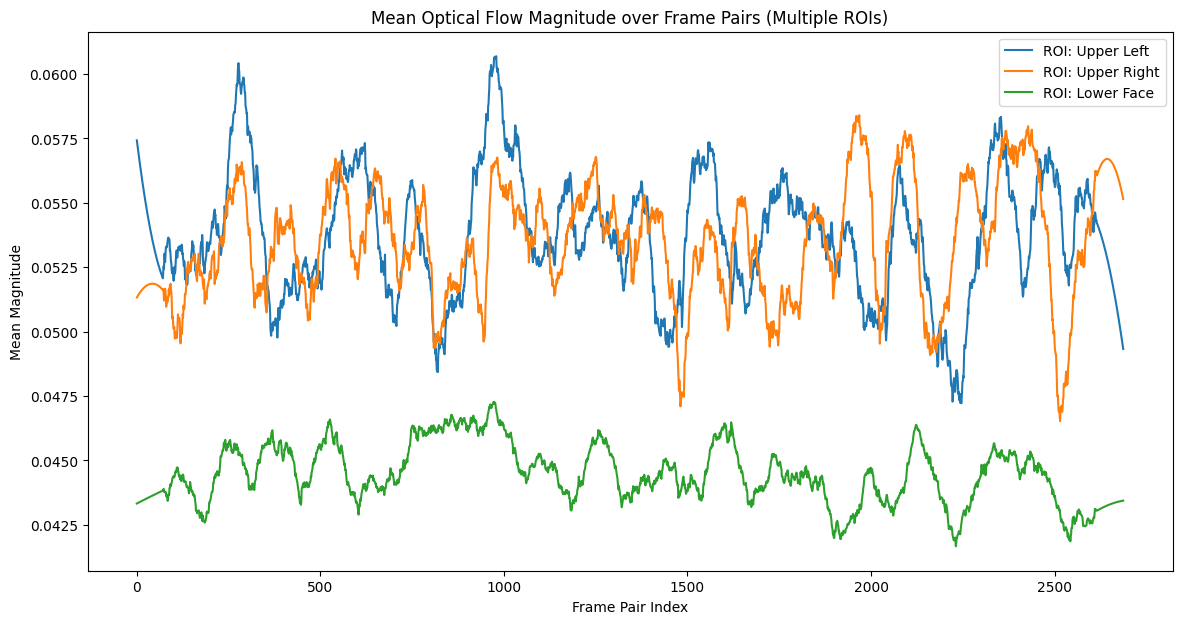

Total frames in video: 2697


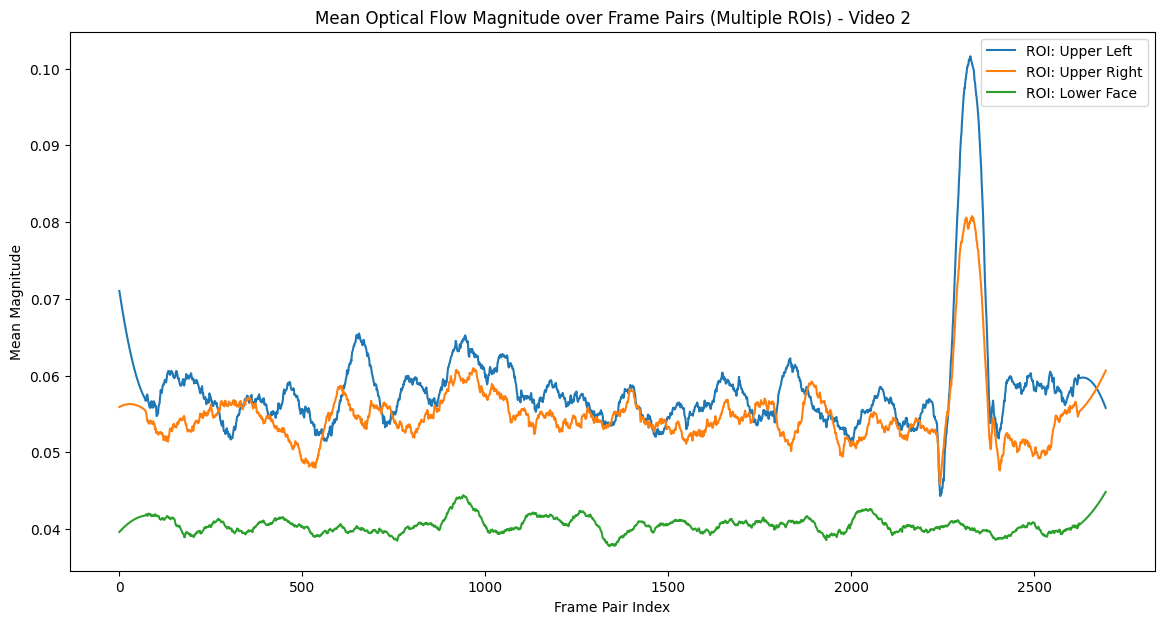

In [ ]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt


VIDEO_PATH = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520125029.avi'

magnitude_stats_roi = process_video_optical_flow_multiple_rois(VIDEO_PATH)

fig1, ax1 = plt.subplots(figsize=(14, 7))
for roi_name, stats in magnitude_stats_roi.items():
    smooted_stats_roi = savgol_filter(stats, window_length=144, polyorder=2)

    ax1.plot(smooted_stats_roi, label=f'ROI: {roi_name}')

ax1.set_title('Mean Optical Flow Magnitude over Frame Pairs (Multiple ROIs)')
ax1.set_xlabel('Frame Pair Index')
ax1.set_ylabel('Mean Magnitude')
ax1.legend()
plt.show()

VIDEO_PATH2 = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520132508.avi'
magnitude_stats2_roi = process_video_optical_flow_multiple_rois(VIDEO_PATH2)

fig2, ax2 = plt.subplots(figsize=(14, 7))
for roi_name, stats in magnitude_stats2_roi.items():
    smooted_stats2_roi = savgol_filter(stats, window_length=144, polyorder=2)

    ax2.plot(smooted_stats2_roi, label=f'ROI: {roi_name}')

ax2.set_title('Mean Optical Flow Magnitude over Frame Pairs (Multiple ROIs) - Video 2')
ax2.set_xlabel('Frame Pair Index')
ax2.set_ylabel('Mean Magnitude')
ax2.legend()
plt.show()

mean_stats1 = np.mean(np.array(list(magnitude_stats_roi.values())), axis=1)
mean_stats2 = np.mean(np.array(list(magnitude_stats2_roi.values())), axis=1)

fig, ax = plt.subplots(figsize=(14, 7))

Combining ROI's and compute it with

- Weighted Average (assume the movements on the eyes was important part -> giving more weight)
- L2 Norm (standard of scientific approach)
- Sum (simple and interpretable)

This approach would be used to making the selected ROI's make sense

Total frames in video: 2689


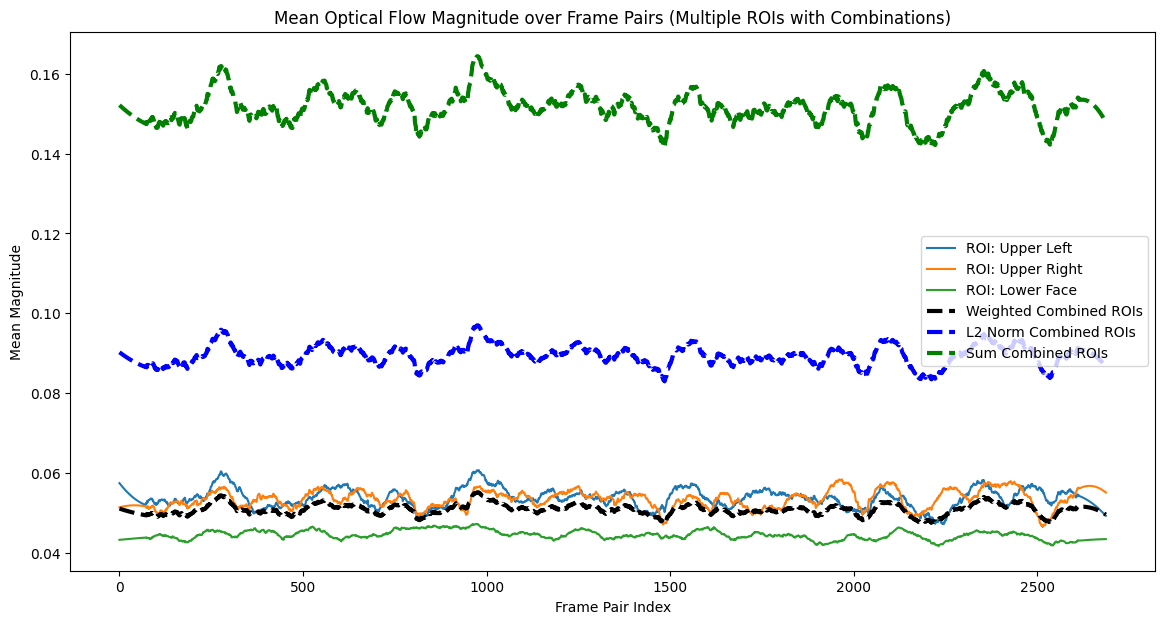

In [8]:
# Weighted average stats calculation for video 1
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt


VIDEO_PATH = '/home/inadio/.undergrade-thesis/datasets/primary/videos/20250520125029.avi'

magnitude_stats_roi = process_video_optical_flow_multiple_rois(VIDEO_PATH)

weight = {
    "Upper Left": 0.35,  # Weight for upper left eye
    "Upper Right": 0.35, # Weight for upper right eye
    "Lower Face": 0.3    # Weight for lower face
}

all_rois_values = np.array(list(magnitude_stats_roi.values()))

weighted_values = []
for idx, (roi_name, stats) in enumerate(magnitude_stats_roi.items()):
    weighted = np.array(stats) * weight[roi_name]
    weighted_values.append(weighted)

combined_weighted_stats1 = np.sum(np.array(weighted_values), axis=0)
smoothed_combined_stats1 = savgol_filter(combined_weighted_stats1, window_length=144, polyorder=2)

combined_l2 = np.linalg.norm(all_rois_values, axis=0)
smoothed_combined_l2 = savgol_filter(combined_l2, window_length=144, polyorder=2)

combined_sum = np.sum(all_rois_values, axis=0)
smoothed_combined_sum = savgol_filter(combined_sum, window_length=144, polyorder=2)

fig, ax = plt.subplots(figsize=(14, 7))

for roi_name, stats in magnitude_stats_roi.items():
    smooted_stats_roi = savgol_filter(stats, window_length=144, polyorder=2)

    ax.plot(smooted_stats_roi, label=f'ROI: {roi_name}')

ax.plot(smoothed_combined_stats1, label='Weighted Combined ROIs', linestyle="--", linewidth=3, color='black')
ax.plot(smoothed_combined_l2, label='L2 Norm Combined ROIs', linestyle="--", linewidth=3, color='blue')
ax.plot(smoothed_combined_sum, label='Sum Combined ROIs', linestyle="--", linewidth=3, color='green')

ax.set_title('Mean Optical Flow Magnitude over Frame Pairs (Multiple ROIs with Combinations)')
ax.set_xlabel('Frame Pair Index')
ax.set_ylabel('Mean Magnitude')
ax.legend()
plt.show()

From the recent paper, the L2-norm was used because of this:

1. In physics and signal processing, the L2-norm is often interpreted as the energy of the signal (in this case, the motion).
2. L2-norm is the standard measure vector length in matematics, using it ensures the magnitudes features are interpretable and consistent.

